# Notebook 0: Exploring the Full HuggingFace Model Ecosystem

This notebook pulls metadata for **all models** on HuggingFace — not just sentence-transformers — and lets you explore the entire landscape programmatically. The HuggingFace website only allows one filter at a time. With the data in a dataframe, you can apply compound filters, cross-tabulate, and visualize freely.

**Two data sources:**
1. **`huggingface_hub` API** — metadata for all 800K+ models (downloads, dates, publishers, libraries, tasks)
2. **MTEB Leaderboard** — standardized benchmark scores for embedding models specifically

**By the end, you'll be able to answer:**
- How many models exist? What libraries and tasks dominate?
- Who publishes models — organizations vs. individuals?
- How can you distinguish official models from fine-tuned variants and student projects?
- Which embedding models are best for clustering and classification (our BERTopic use case)?
- Are the most downloaded models actually the best?

**Warning:** Pulling all models takes 5–15 minutes. We cache the results so you only do this once.

---

## 1. Setup

In [1]:
# Install required packages (uncomment as needed)
# !pip install huggingface_hub pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
print("Libraries loaded.")

Libraries loaded.


---
# Section 1: The Full Ecosystem — Every Model on HuggingFace
---

We pull metadata for **all models** on the hub. This is a massive dataset — 800K+ models. We extract every available metadata field to enable rich exploration.

In [3]:
# ============================================================
# OPTION A: Pull live from HuggingFace API (takes 5-15 min)
# OPTION B: Load from pre-saved CSV (instant, for classroom use)
# ============================================================

CACHE_FILE = 'hf_all_models_cache.csv'
USE_CACHE = False  # Set True after first run or for offline use

if USE_CACHE and os.path.exists(CACHE_FILE):
    print(f"Loading cached data from {CACHE_FILE}...")
    hf_df = pd.read_csv(CACHE_FILE, low_memory=False)
    print(f"Loaded {len(hf_df):,} models from cache.")
else:
    from huggingface_hub import HfApi
    
    print("Fetching ALL models from HuggingFace Hub...")
    print("This will take 5-15 minutes. Go get coffee.\n")
    
    api = HfApi()
    
    # Pull everything — no filters
    start_time = datetime.now()
    models = list(api.list_models(sort='downloads', direction=-1))
    elapsed = (datetime.now() - start_time).total_seconds()
    
    print(f"Retrieved {len(models):,} models in {elapsed:.0f} seconds.\n")
    
    # Extract ALL available metadata
    records = []
    for m in models:
        tags = getattr(m, 'tags', []) or []
        records.append({
            'model_id': m.id,
            'author': m.id.split('/')[0] if '/' in m.id else 'unknown',
            'model_name': m.id.split('/')[-1],
            'downloads': getattr(m, 'downloads', 0) or 0,
            'likes': getattr(m, 'likes', 0) or 0,
            'last_modified': str(getattr(m, 'last_modified', '')),
            'created_at': str(getattr(m, 'created_at', '')),
            'pipeline_tag': getattr(m, 'pipeline_tag', '') or '',
            'library_name': getattr(m, 'library_name', '') or '',
            'private': getattr(m, 'private', False),
            'gated': str(getattr(m, 'gated', '')),
            'tags': ', '.join(tags),
            'num_tags': len(tags),
            # Derived fields for analysis
            'has_finetuned_in_name': 1 if any(x in m.id.lower() for x in ['finetuned', 'fine-tuned', 'ft-', '-ft']) else 0,
            'has_generated_from_trainer': 1 if 'generated_from_trainer' in tags else 0,
            'is_gguf': 1 if any('gguf' in t.lower() for t in tags) else 0,
        })
    
    hf_df = pd.DataFrame(records)
    
    # Parse dates
    hf_df['last_modified'] = pd.to_datetime(hf_df['last_modified'], errors='coerce')
    hf_df['created_at'] = pd.to_datetime(hf_df['created_at'], errors='coerce')
    
    # Save cache
    hf_df.to_csv(CACHE_FILE, index=False)
    print(f"Saved to {CACHE_FILE} ({os.path.getsize(CACHE_FILE) / 1e6:.1f} MB)")

print(f"\nDataset: {len(hf_df):,} models")
print(f"Columns: {list(hf_df.columns)}")
hf_df.head(5)

Fetching ALL models from HuggingFace Hub...
This will take 5-15 minutes. Go get coffee.



HTTP Error 429 thrown while requesting GET https://huggingface.co/api/models?sort=downloads&direction=-1&cursor=eyIkb3IiOlt7ImRvd25sb2FkcyI6MCwiX2lkIjp7IiRndCI6IjY1YTc0NjU2Y2M2Nzc4N2E4ZDBkYzg1YSJ9fSx7ImRvd25sb2FkcyI6eyIkbHQiOjB9fSx7ImRvd25sb2FkcyI6bnVsbH1dfQ%3D%3D
Rate limited. Waiting 83.0s before retry [Retry 1/5].
HTTP Error 429 thrown while requesting GET https://huggingface.co/api/models?sort=downloads&direction=-1&cursor=eyIkb3IiOlt7ImRvd25sb2FkcyI6MCwiX2lkIjp7IiRndCI6IjY4OGJiOTlkZjExMGM2MzAyYmEwZjkzNSJ9fSx7ImRvd25sb2FkcyI6eyIkbHQiOjB9fSx7ImRvd25sb2FkcyI6bnVsbH1dfQ%3D%3D
Rate limited. Waiting 195.0s before retry [Retry 1/5].


Retrieved 2,711,477 models in 560 seconds.

Saved to hf_all_models_cache.csv (646.3 MB)

Dataset: 2,711,477 models
Columns: ['model_id', 'author', 'model_name', 'downloads', 'likes', 'last_modified', 'created_at', 'pipeline_tag', 'library_name', 'private', 'gated', 'tags', 'num_tags', 'has_finetuned_in_name', 'has_generated_from_trainer', 'is_gguf']


,model_id,author,model_name,downloads,likes,last_modified,created_at,pipeline_tag,library_name,private,gated,tags,num_tags,has_finetuned_in_name,has_generated_from_trainer,is_gguf
0,sentence-transformers/all-MiniLM-L6-v2,sentence-transformers,all-MiniLM-L6-v2,205055121,4577,NaT,2022-03-02 23:29:05+00:00,sentence-similarity,sentence-transformers,False,None,"sentence-transformers, pytorch, tf, rust, onnx...",44,0,0,0
1,google-bert/bert-base-uncased,google-bert,bert-base-uncased,69145651,2587,NaT,2022-03-02 23:29:04+00:00,fill-mask,transformers,False,None,"transformers, pytorch, tf, jax, rust, coreml, ...",19,0,0,0
2,google/electra-base-discriminator,google,electra-base-discriminator,51174546,85,NaT,2022-03-02 23:29:05+00:00,,transformers,False,None,"transformers, pytorch, tf, jax, rust, electra,...",12,0,0,0
3,Falconsai/nsfw_image_detection,Falconsai,nsfw_image_detection,41775237,1012,NaT,2023-10-13 23:50:01+00:00,image-classification,transformers,False,None,"transformers, pytorch, safetensors, vit, image...",10,0,0,0
4,sentence-transformers/all-mpnet-base-v2,sentence-transformers,all-mpnet-base-v2,28446166,1256,NaT,2022-03-02 23:29:05+00:00,sentence-similarity,sentence-transformers,False,None,"sentence-transformers, pytorch, onnx, safetens...",42,0,0,0


### The big picture — how big is HuggingFace?

In [4]:
print(f"Total models on HuggingFace: {len(hf_df):,}")
print(f"Total downloads across all models: {hf_df['downloads'].sum():,.0f}")
print(f"Total likes across all models: {hf_df['likes'].sum():,.0f}")
print(f"Unique authors/organizations: {hf_df['author'].nunique():,}")
print(f"Unique libraries: {hf_df['library_name'].nunique()}")
print(f"Unique tasks (pipeline_tag): {hf_df['pipeline_tag'].nunique()}")

print(f"\nDownload distribution:")
print(hf_df['downloads'].describe().apply(lambda x: f"{x:,.0f}"))

Total models on HuggingFace: 2,711,477
Total downloads across all models: 2,244,373,759
Total likes across all models: 2,152,171
Unique authors/organizations: 509,516
Unique libraries: 1100
Unique tasks (pipeline_tag): 57

Download distribution:
count      2,711,477
mean             828
std          151,213
min                0
25%                0
50%                0
75%                1
max      205,055,121
Name: downloads, dtype: object


### What libraries and tasks exist?

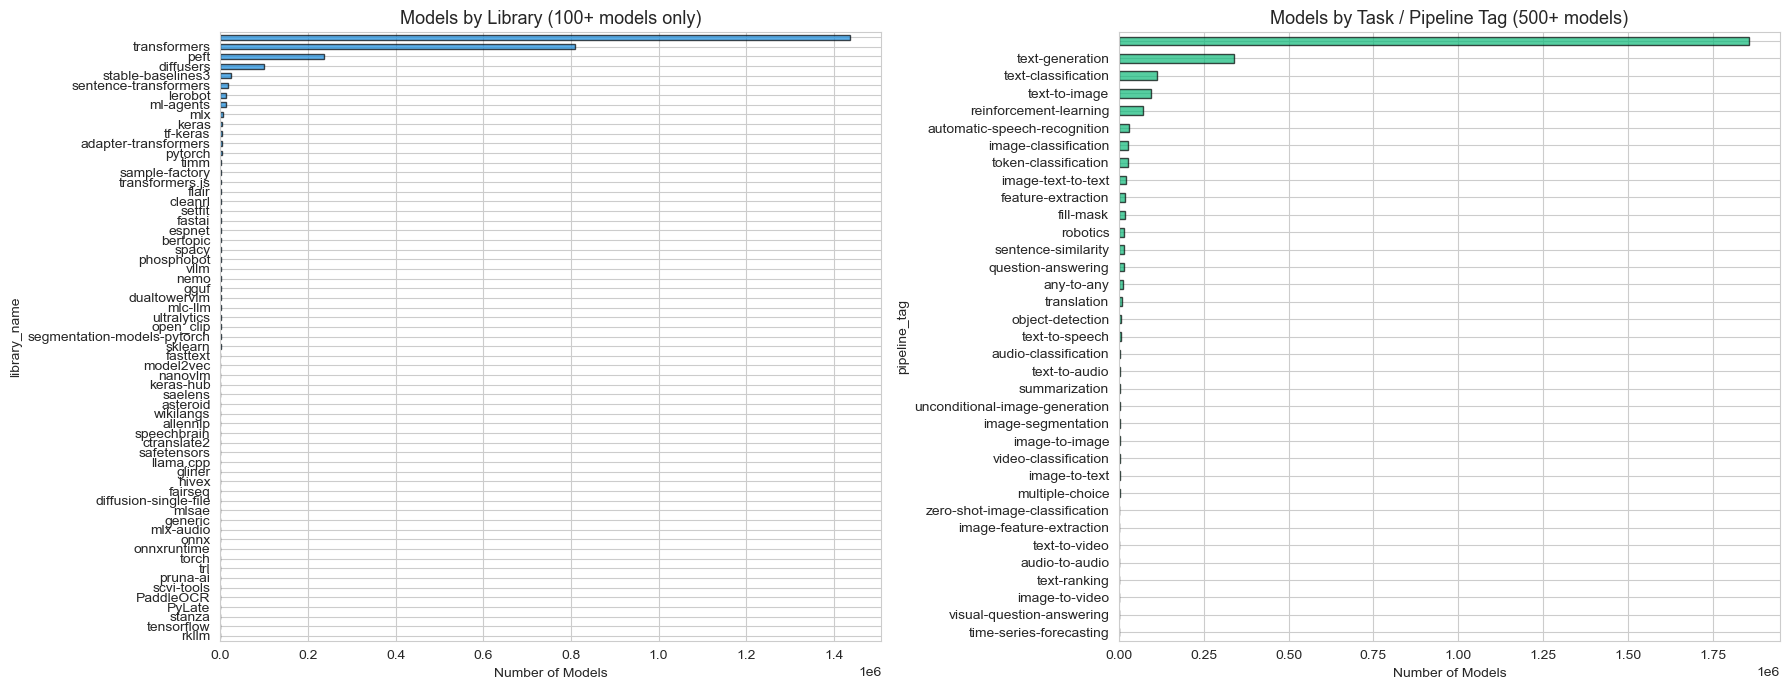


All libraries: ['', 'transformers', 'peft', 'diffusers', 'stable-baselines3', 'sentence-transformers', 'lerobot', 'ml-agents', 'mlx', 'keras', 'tf-keras', 'adapter-transformers', 'pytorch', 'timm', 'sample-factory', 'transformers.js', 'flair', 'cleanrl', 'setfit', 'fastai', 'espnet', 'bertopic', 'spacy', 'phosphobot', 'vllm', 'nemo', 'gguf', 'dualtowervlm', 'mlc-llm', 'ultralytics']

All tasks: ['', 'text-generation', 'text-classification', 'text-to-image', 'reinforcement-learning', 'automatic-speech-recognition', 'image-classification', 'token-classification', 'image-text-to-text', 'feature-extraction', 'fill-mask', 'robotics', 'sentence-similarity', 'question-answering', 'any-to-any', 'translation', 'object-detection', 'text-to-speech', 'audio-classification', 'text-to-audio', 'summarization', 'unconditional-image-generation', 'image-segmentation', 'image-to-image', 'video-classification', 'image-to-text', 'multiple-choice', 'zero-shot-image-classification', 'image-feature-extractio

In [5]:
# Library distribution
lib_counts = hf_df['library_name'].value_counts()
lib_counts_top = lib_counts[lib_counts > 100]  # only show libraries with 100+ models

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

lib_counts_top.plot(kind='barh', ax=axes[0], color='#1a8fe0', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Models')
axes[0].set_title('Models by Library (100+ models only)', fontsize=13)
axes[0].invert_yaxis()

# Task distribution
task_counts = hf_df['pipeline_tag'].value_counts()
task_counts_top = task_counts[task_counts > 500]

task_counts_top.plot(kind='barh', ax=axes[1], color='#0eba7a', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Number of Models')
axes[1].set_title('Models by Task / Pipeline Tag (500+ models)', fontsize=13)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nAll libraries: {list(lib_counts.index[:30])}")
print(f"\nAll tasks: {list(task_counts.index[:30])}")

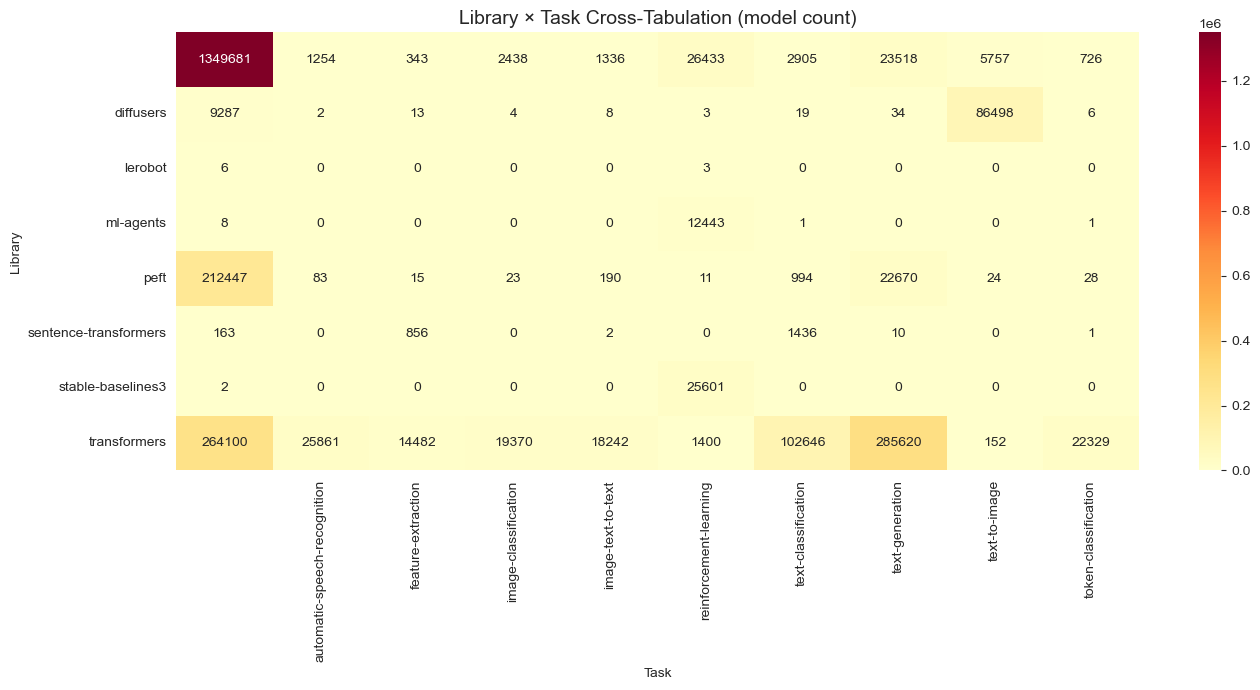


This is the kind of compound analysis the HuggingFace website can't do.
You can see which libraries dominate which tasks.


In [6]:
# Cross-tabulation: Library × Task (top combos)
top_libs = lib_counts.head(8).index.tolist()
top_tasks = task_counts.head(10).index.tolist()

cross = pd.crosstab(
    hf_df[hf_df['library_name'].isin(top_libs)]['library_name'],
    hf_df[hf_df['pipeline_tag'].isin(top_tasks)]['pipeline_tag']
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cross, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Library × Task Cross-Tabulation (model count)', fontsize=14)
ax.set_xlabel('Task')
ax.set_ylabel('Library')
plt.tight_layout()
plt.show()

print("\nThis is the kind of compound analysis the HuggingFace website can't do.")
print("You can see which libraries dominate which tasks.")

### Download distribution — the long tail

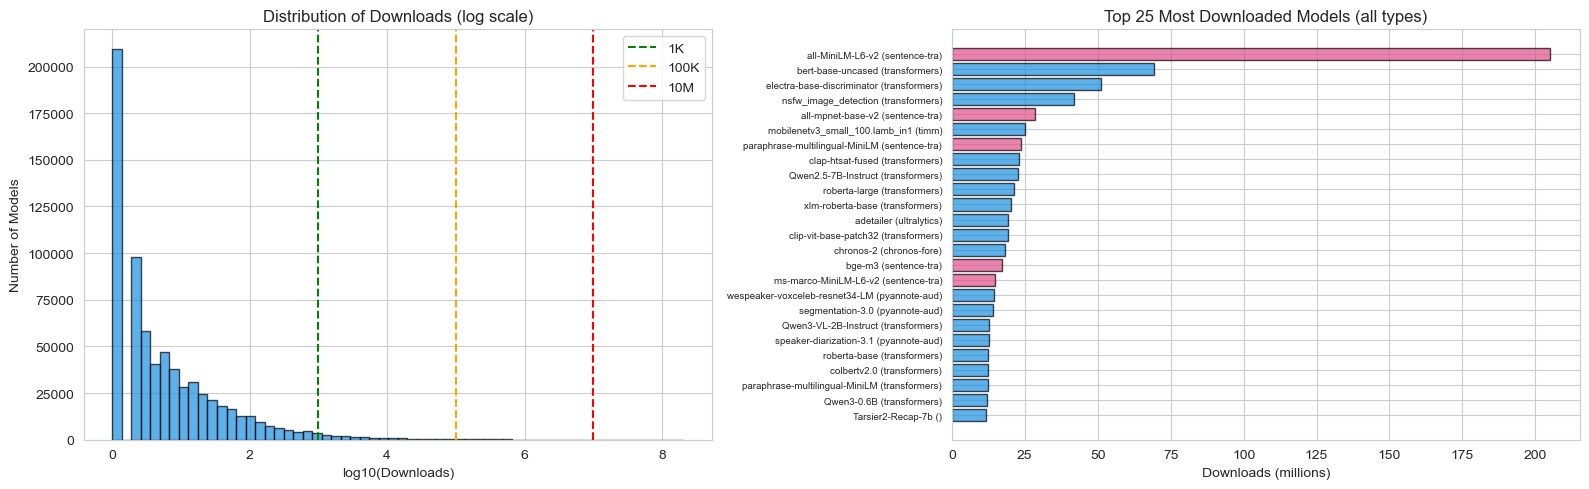


Models with 0 downloads: 1,997,650
Models with >1K downloads: 18,019
Models with >100K downloads: 1,824
Models with >1M downloads: 325


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Log-scale histogram
downloads_nonzero = hf_df[hf_df['downloads'] > 0]['downloads']
axes[0].hist(np.log10(downloads_nonzero), bins=60, color='#1a8fe0', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('log10(Downloads)')
axes[0].set_ylabel('Number of Models')
axes[0].set_title('Distribution of Downloads (log scale)')
axes[0].axvline(np.log10(1000), color='green', linestyle='--', label='1K')
axes[0].axvline(np.log10(100000), color='orange', linestyle='--', label='100K')
axes[0].axvline(np.log10(10000000), color='red', linestyle='--', label='10M')
axes[0].legend()

# Top 25 most downloaded overall
top25 = hf_df.nlargest(25, 'downloads')
colors = ['#e04e8a' if 'sentence' in str(row['library_name']).lower() else '#1a8fe0' 
          for _, row in top25.iterrows()]
axes[1].barh(range(len(top25)), top25['downloads'] / 1e6, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top25)))
axes[1].set_yticklabels([f"{row['model_name'][:30]} ({row['library_name'][:12]})" 
                         for _, row in top25.iterrows()], fontsize=7)
axes[1].set_xlabel('Downloads (millions)')
axes[1].set_title('Top 25 Most Downloaded Models (all types)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nModels with 0 downloads: {(hf_df['downloads'] == 0).sum():,}")
print(f"Models with >1K downloads: {(hf_df['downloads'] >= 1000).sum():,}")
print(f"Models with >100K downloads: {(hf_df['downloads'] >= 100000).sum():,}")
print(f"Models with >1M downloads: {(hf_df['downloads'] >= 1000000).sum():,}")

### Who publishes models?

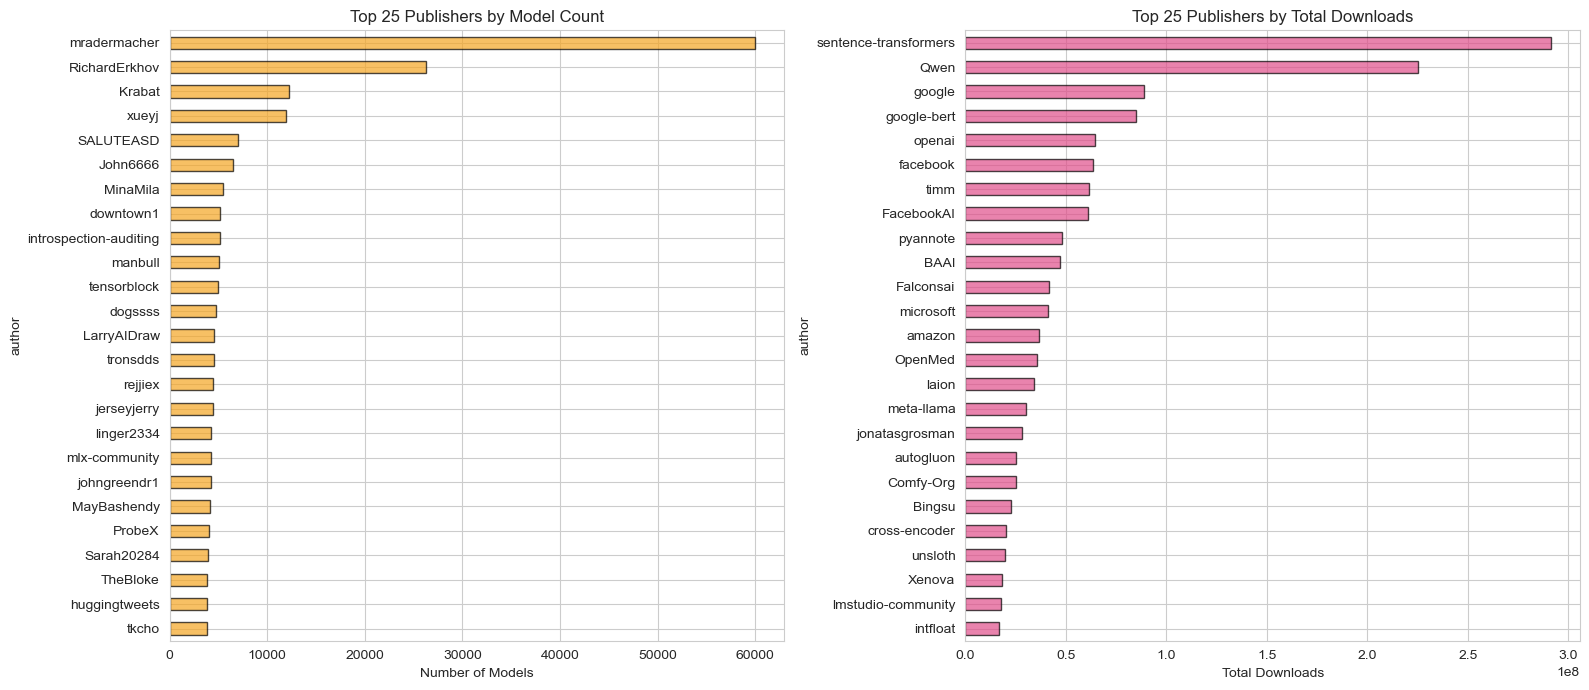


Publishing many models ≠ having many downloads.
Compare the two lists — which names appear on both? Which only on one?


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Top 25 by model count
top_pub_count = hf_df['author'].value_counts().head(25)
top_pub_count.plot(kind='barh', ax=axes[0], color='#f5a623', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Models')
axes[0].set_title('Top 25 Publishers by Model Count')
axes[0].invert_yaxis()

# Top 25 by total downloads
top_pub_dl = hf_df.groupby('author')['downloads'].sum().nlargest(25)
top_pub_dl.plot(kind='barh', ax=axes[1], color='#e04e8a', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Total Downloads')
axes[1].set_title('Top 25 Publishers by Total Downloads')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nPublishing many models ≠ having many downloads.")
print("Compare the two lists — which names appear on both? Which only on one?")

### Growth over time

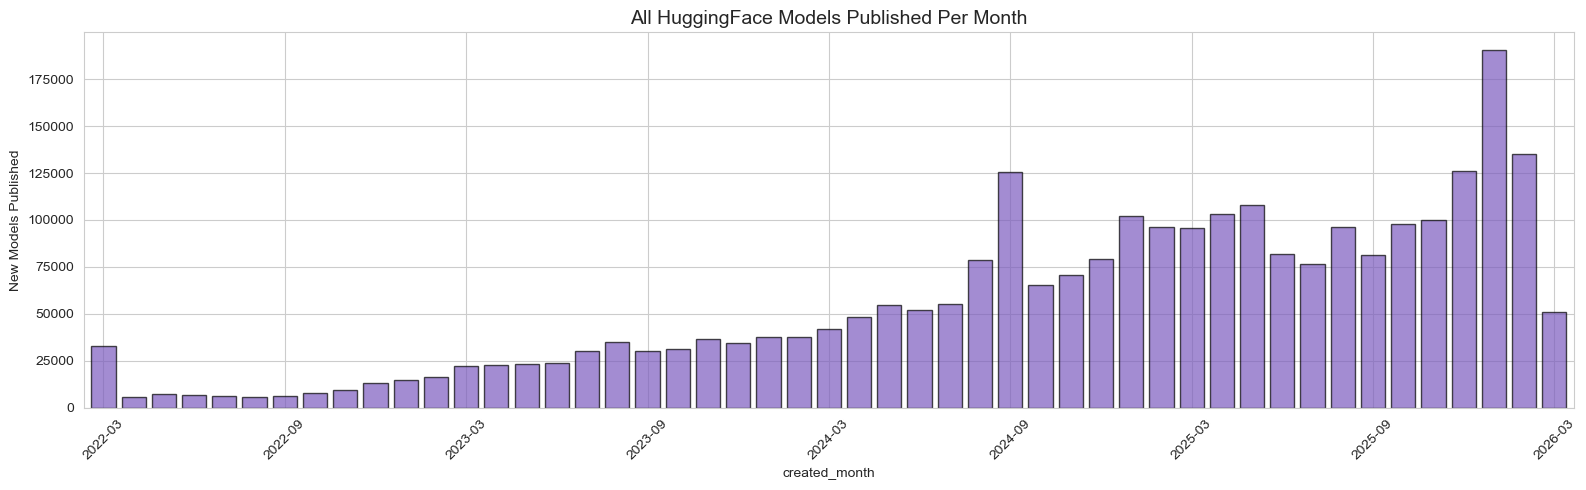

In [9]:
if hf_df['created_at'].notna().sum() > 1000:
    hf_df['created_month'] = pd.to_datetime(hf_df['created_at'], errors='coerce').dt.to_period('M')
    monthly = hf_df.groupby('created_month').size()
    monthly = monthly[monthly.index >= '2020-01']
    
    fig, ax = plt.subplots(figsize=(16, 5))
    monthly.plot(kind='bar', ax=ax, color='#7c5cbf', edgecolor='black', alpha=0.7, width=0.8)
    ax.set_ylabel('New Models Published')
    ax.set_title('All HuggingFace Models Published Per Month', fontsize=14)
    
    tick_positions = range(0, len(monthly), 6)
    ax.set_xticks(list(tick_positions))
    ax.set_xticklabels([str(monthly.index[i]) for i in tick_positions], rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("Created date not available. Skipping.")

### Identifying model types: official, fine-tuned, student projects

There's no clean metadata flag for this, but we can infer from multiple signals.

In [10]:
# Heuristic classification of model types
def classify_model(row):
    """Heuristic to guess whether a model is official, fine-tuned, or a student project."""
    known_orgs = ['google', 'meta-llama', 'microsoft', 'openai', 'facebook', 'huggingface',
                  'sentence-transformers', 'BAAI', 'intfloat', 'stabilityai', 'mistralai',
                  'Qwen', 'nvidia', 'apple', 'deepseek-ai', 'allenai', 'EleutherAI',
                  'bigscience', 'tiiuae', 'jinaai', 'nomic-ai', 'mixedbread-ai', 'thenlper',
                  'Alibaba-NLP', 'cohere', 'amazon', 'Salesforce']
    
    author = row['author']
    downloads = row['downloads']
    name = row['model_name'].lower()
    is_finetuned = row['has_finetuned_in_name']
    is_trainer = row['has_generated_from_trainer']
    
    if author in known_orgs:
        return 'Official / Major Org'
    elif downloads >= 100000:
        return 'Widely Used'
    elif is_trainer and downloads < 100:
        return 'Likely Student Project'
    elif is_finetuned:
        return 'Fine-tuned Variant'
    elif downloads < 10:
        return 'Minimal Use'
    else:
        return 'Community'

hf_df['model_type'] = hf_df.apply(classify_model, axis=1)

type_counts = hf_df['model_type'].value_counts()
print("Model Type Distribution (heuristic):")
print("=" * 50)
for mtype, count in type_counts.items():
    pct = count / len(hf_df) * 100
    print(f"  {mtype:<25} {count:>10,}  ({pct:>5.1f}%)")

print(f"\nTotal: {len(hf_df):,}")

Model Type Distribution (heuristic):
  Minimal Use                2,132,815  ( 78.7%)
  Likely Student Project       262,626  (  9.7%)
  Community                    198,378  (  7.3%)
  Fine-tuned Variant           108,062  (  4.0%)
  Official / Major Org           8,362  (  0.3%)
  Widely Used                    1,234  (  0.0%)

Total: 2,711,477


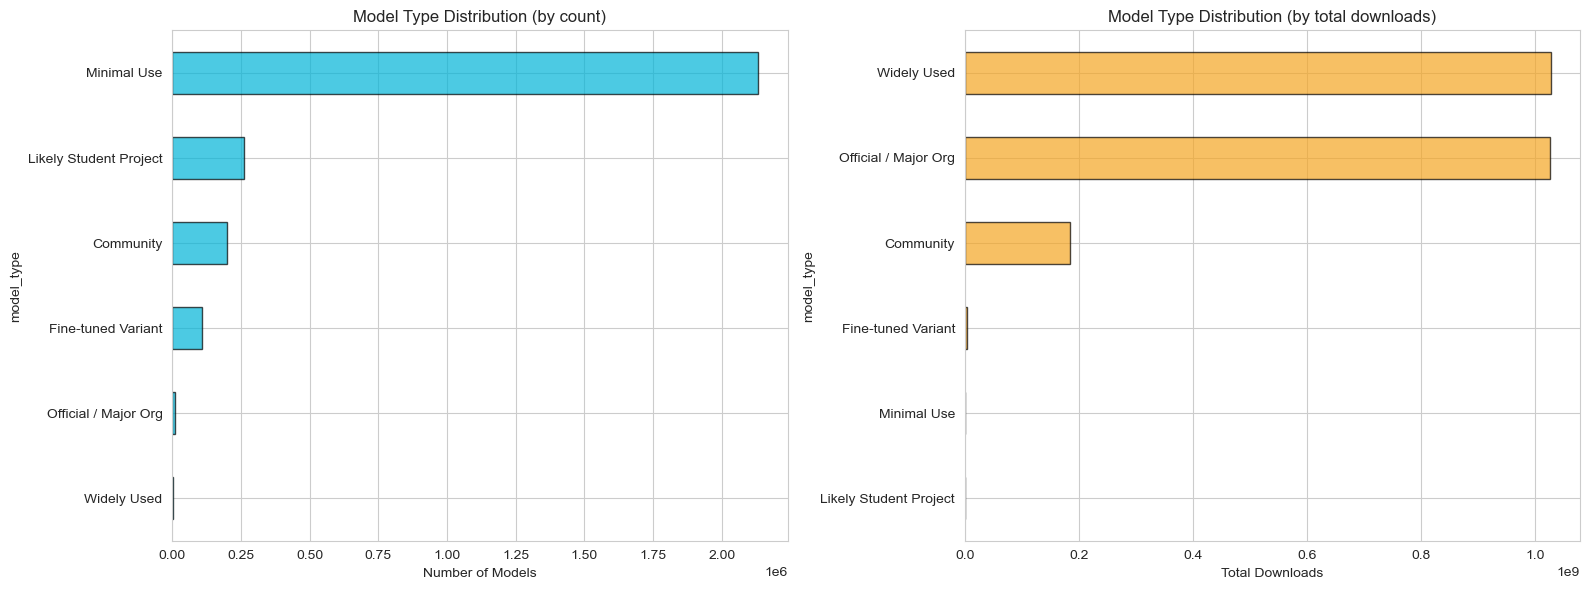


Most models are minimal-use or student projects by count.
But almost all downloads go to Official/Major Org and Widely Used models.
This is a classic long-tail distribution.


In [11]:
# Visualize model type distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# By count
type_counts.plot(kind='barh', ax=axes[0], color='#00b4d8', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Number of Models')
axes[0].set_title('Model Type Distribution (by count)')
axes[0].invert_yaxis()

# By total downloads (very different picture)
type_downloads = hf_df.groupby('model_type')['downloads'].sum().sort_values(ascending=True)
type_downloads.plot(kind='barh', ax=axes[1], color='#f5a623', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Total Downloads')
axes[1].set_title('Model Type Distribution (by total downloads)')

plt.tight_layout()
plt.show()

print("\nMost models are minimal-use or student projects by count.")
print("But almost all downloads go to Official/Major Org and Widely Used models.")
print("This is a classic long-tail distribution.")

In [12]:
# Signals that suggest a model is a student project or auto-generated
print(f"Models with 'finetuned' or 'fine-tuned' in name: {hf_df['has_finetuned_in_name'].sum():,}")
print(f"Models with 'generated_from_trainer' tag: {hf_df['has_generated_from_trainer'].sum():,}")
print(f"Models that are GGUF quantizations: {hf_df['is_gguf'].sum():,}")
print(f"Models with 0 downloads: {(hf_df['downloads'] == 0).sum():,}")
print(f"Models with 0 likes: {(hf_df['likes'] == 0).sum():,}")
print(f"\nMany 'models' on the hub are homework assignments, failed experiments,")
print(f"or auto-generated outputs from training scripts that were never used.")

Models with 'finetuned' or 'fine-tuned' in name: 152,694
Models with 'generated_from_trainer' tag: 265,877
Models that are GGUF quantizations: 163,970
Models with 0 downloads: 1,997,650
Models with 0 likes: 2,522,376

Many 'models' on the hub are homework assignments, failed experiments,
or auto-generated outputs from training scripts that were never used.


### Compound filters — the power of a dataframe

In [13]:
# ============================================================
# COMPOUND FILTERS — what the HuggingFace website can't do
# ============================================================

# Filter 1: Sentence-transformer models specifically (what we use for BERTopic)
st_models = hf_df[hf_df['library_name'] == 'sentence-transformers'].sort_values('downloads', ascending=False)
print(f"Sentence-Transformer models: {len(st_models):,}")
print(st_models[['model_id', 'downloads', 'likes', 'pipeline_tag']].head(15).to_string(index=False))

Sentence-Transformer models: 16,797
                                                   model_id  downloads  likes        pipeline_tag
                     sentence-transformers/all-MiniLM-L6-v2  205055121   4577 sentence-similarity
                    sentence-transformers/all-mpnet-base-v2   28446166   1256 sentence-similarity
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2   23857870   1161 sentence-similarity
                                                BAAI/bge-m3   17211418   2830 sentence-similarity
                        cross-encoder/ms-marco-MiniLM-L6-v2   14665705    199        text-ranking
                             nomic-ai/nomic-embed-text-v1.5    8677077    780 sentence-similarity
                                     BAAI/bge-small-en-v1.5    7742207    421  feature-extraction
sentence-transformers/paraphrase-multilingual-mpnet-base-v2    6610624    455 sentence-similarity
                                     BAAI/bge-large-en-v1.5    6034342    633  fea

In [14]:
# Filter 2: Computer vision models with 100K+ downloads from major orgs
cv_tasks = ['image-classification', 'object-detection', 'image-segmentation', 
            'image-to-image', 'depth-estimation']
cv_popular = hf_df[
    (hf_df['pipeline_tag'].isin(cv_tasks)) &
    (hf_df['downloads'] >= 100000) &
    (hf_df['model_type'] == 'Official / Major Org')
].sort_values('downloads', ascending=False)

print(f"\nCV models from major orgs with 100K+ downloads: {len(cv_popular)}")
print(cv_popular[['model_id', 'downloads', 'pipeline_tag']].head(15).to_string(index=False))


CV models from major orgs with 100K+ downloads: 21
                                                  model_id  downloads         pipeline_tag
                               google/vit-base-patch16-224    4102167 image-classification
                     microsoft/table-transformer-detection    3993468     object-detection
                                     apple/mobilevit-small    2934513 image-classification
         microsoft/table-transformer-structure-recognition    1523661     object-detection
               microsoft/beit-base-patch16-224-pt22k-ft22k     898265 image-classification
             facebook/mask2former-swin-large-coco-panoptic     523344   image-segmentation
                 nvidia/segformer-b0-finetuned-ade-512-512     486339   image-segmentation
       facebook/mask2former-swin-large-cityscapes-semantic     438731   image-segmentation
                 microsoft/swinv2-tiny-patch4-window16-256     368366 image-classification
               stabilityai/stable-diff

In [15]:
# Filter 3: Text generation models (LLMs) — the most hyped category
llms = hf_df[hf_df['pipeline_tag'] == 'text-generation'].sort_values('downloads', ascending=False)
print(f"\nText generation models (LLMs): {len(llms):,}")
print(f"  From major orgs: {llms[llms['model_type'] == 'Official / Major Org'].shape[0]:,}")
print(f"  GGUF quantizations: {llms['is_gguf'].sum():,}")
print(f"  Fine-tuned variants: {llms['has_finetuned_in_name'].sum():,}")
print(f"\nTop 10:")
print(llms[['model_id', 'downloads', 'author']].head(10).to_string(index=False))


Text generation models (LLMs): 340,157
  From major orgs: 1,874
  GGUF quantizations: 28,092
  Fine-tuned variants: 21,466

Top 10:
                        model_id  downloads           author
        Qwen/Qwen2.5-7B-Instruct   22813513             Qwen
                 Qwen/Qwen3-0.6B   12155633             Qwen
           openai-community/gpt2   10803658 openai-community
      Qwen/Qwen2.5-1.5B-Instruct    8750699             Qwen
                   Qwen/Qwen3-8B    8216721             Qwen
              openai/gpt-oss-20b    7441873           openai
meta-llama/Llama-3.1-8B-Instruct    7263713       meta-llama
        Qwen/Qwen2.5-3B-Instruct    7047486             Qwen
                 Qwen/Qwen3-1.7B    6959052             Qwen
               facebook/opt-125m    6844284         facebook


In [16]:
# Filter 4: Popular + recent + NOT fine-tuned (likely original/official models)
original_recent = hf_df[
    (hf_df['downloads'] >= 50000) &
    (hf_df['last_modified'] >= '2024-06-01') &
    (hf_df['has_finetuned_in_name'] == 0) &
    (hf_df['has_generated_from_trainer'] == 0)
].sort_values('downloads', ascending=False)

print(f"Popular (50K+), recent, non-fine-tuned models: {len(original_recent):,}")
print(original_recent[['model_id', 'downloads', 'library_name', 'pipeline_tag']].head(20).to_string(index=False))

Popular (50K+), recent, non-fine-tuned models: 0
Empty DataFrame
Columns: [model_id, downloads, library_name, pipeline_tag]
Index: []


In [17]:
# Filter 5: Multilingual models across all tasks
multilingual = hf_df[
    hf_df['tags'].str.contains('multilingual', case=False, na=False)
].sort_values('downloads', ascending=False)

print(f"Multilingual models (all types): {len(multilingual):,}")
print(f"\nBy library:")
print(multilingual['library_name'].value_counts().head(10).to_string())
print(f"\nTop 10 by downloads:")
print(multilingual[['model_id', 'downloads', 'library_name']].head(10).to_string(index=False))

Multilingual models (all types): 14,748

By library:
library_name
transformers             6418
                         4406
sentence-transformers    1344
flair                    1282
setfit                    186
espnet                    141
peft                      140
mlx                       128
model2vec                  91
nemo                       73

Top 10 by downloads:
                                                   model_id  downloads          library_name
sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2   23857870 sentence-transformers
                                FacebookAI/xlm-roberta-base   20162557          transformers
               Xenova/paraphrase-multilingual-MiniLM-L12-v2   12231351       transformers.js
sentence-transformers/paraphrase-multilingual-mpnet-base-v2    6610624 sentence-transformers
                               FacebookAI/xlm-roberta-large    6480427          transformers
                             intfloat/multilingual-e5-

In [18]:
# Filter 6: Search by name pattern
search_term = 'bert'  # Change this to search for anything

matches = hf_df[
    hf_df['model_id'].str.contains(search_term, case=False, na=False)
].sort_values('downloads', ascending=False)

print(f"Models matching '{search_term}': {len(matches):,}")
print(f"\nBy library:")
print(matches['library_name'].value_counts().head(8).to_string())
print(f"\nTop 10 by downloads:")
print(matches[['model_id', 'downloads', 'library_name', 'pipeline_tag']].head(10).to_string(index=False))

Models matching 'bert': 155,553

By library:
library_name
transformers             103058
                          42594
sentence-transformers      4048
peft                       1811
flair                       889
adapter-transformers        740
bertopic                    575
diffusers                   292

Top 10 by downloads:
                                  model_id  downloads library_name        pipeline_tag
             google-bert/bert-base-uncased   69145651 transformers           fill-mask
                  FacebookAI/roberta-large   21360128 transformers           fill-mask
               FacebookAI/xlm-roberta-base   20162557 transformers           fill-mask
                   FacebookAI/roberta-base   12445872 transformers           fill-mask
                    colbert-ir/colbertv2.0   12341766 transformers                    
        distilbert/distilbert-base-uncased    7643113 transformers           fill-mask
              FacebookAI/xlm-roberta-large    6480427 t

---
# Section 2: Quality Rankings — MTEB Leaderboard
---

**MTEB** = Massive Text Embedding Benchmark. It evaluates embedding models across standardized tasks:
- **Classification** — can embeddings distinguish categories?
- **Clustering** — do similar documents group together? (most relevant for BERTopic)
- **Semantic Textual Similarity (STS)** — do similar sentences get similar vectors?
- **Retrieval** — can you find relevant documents given a query?

The leaderboard: `huggingface.co/spaces/mteb/leaderboard`

In [19]:
# Curated MTEB reference table — well-known models with published scores
# Scores are approximate and representative of published benchmarks
MTEB_CACHE = 'mteb_leaderboard_cache.csv'

if os.path.exists(MTEB_CACHE):
    mteb_df = pd.read_csv(MTEB_CACHE)
    print(f"Loaded {len(mteb_df)} models from MTEB cache.")
else:
    mteb_records = [
        ('sentence-transformers/all-MiniLM-L6-v2', 384, 256, 22, 56.3, 63.1, 42.4, 78.9, 41.9),
        ('sentence-transformers/all-MiniLM-L12-v2', 384, 256, 33, 56.5, 63.2, 41.8, 79.8, 42.7),
        ('sentence-transformers/all-mpnet-base-v2', 768, 384, 109, 57.8, 65.2, 43.7, 80.3, 43.8),
        ('sentence-transformers/all-distilroberta-v1', 768, 512, 82, 55.1, 62.0, 38.1, 78.1, 41.2),
        ('BAAI/bge-small-en-v1.5', 384, 512, 33, 62.2, 75.5, 51.0, 81.2, 51.7),
        ('BAAI/bge-base-en-v1.5', 768, 512, 109, 63.6, 76.0, 52.3, 82.4, 53.3),
        ('BAAI/bge-large-en-v1.5', 1024, 512, 335, 64.2, 76.5, 53.0, 83.1, 54.3),
        ('intfloat/e5-small-v2', 384, 512, 33, 61.5, 74.8, 49.5, 80.4, 49.0),
        ('intfloat/e5-base-v2', 768, 512, 109, 62.6, 75.5, 50.5, 82.0, 50.3),
        ('intfloat/e5-large-v2', 1024, 512, 335, 64.1, 76.2, 52.8, 82.9, 53.5),
        ('thenlper/gte-small', 384, 512, 33, 61.4, 74.3, 48.8, 80.0, 49.5),
        ('thenlper/gte-base', 768, 512, 109, 62.4, 74.9, 51.2, 82.3, 51.1),
        ('thenlper/gte-large', 1024, 512, 335, 63.1, 75.5, 52.0, 83.0, 52.5),
        ('jinaai/jina-embeddings-v2-small-en', 512, 8192, 33, 60.4, 73.5, 47.5, 79.8, 47.0),
        ('jinaai/jina-embeddings-v2-base-en', 768, 8192, 137, 62.3, 74.8, 49.8, 81.5, 50.5),
        ('nomic-ai/nomic-embed-text-v1.5', 768, 8192, 137, 62.3, 74.5, 50.2, 82.1, 50.8),
        ('mixedbread-ai/mxbai-embed-large-v1', 1024, 512, 335, 64.7, 76.8, 53.5, 83.5, 54.8),
        ('Alibaba-NLP/gte-Qwen2-1.5B-instruct', 1536, 32768, 1540, 67.2, 78.0, 56.9, 85.2, 57.8),
    ]
    
    mteb_df = pd.DataFrame(mteb_records, columns=[
        'model_id', 'dimensions', 'max_tokens', 'params_millions',
        'mteb_avg', 'classification', 'clustering', 'sts', 'retrieval'
    ])
    mteb_df['author'] = mteb_df['model_id'].apply(lambda x: x.split('/')[0])
    mteb_df['model_name'] = mteb_df['model_id'].apply(lambda x: x.split('/')[-1])
    mteb_df.to_csv(MTEB_CACHE, index=False)
    print(f"Built curated MTEB table: {len(mteb_df)} models.")

mteb_df

Loaded 18 models from MTEB cache.


,model_id,dimensions,max_tokens,params_millions,mteb_avg,classification,clustering,sts,retrieval,author,model_name
0,sentence-transformers/all-MiniLM-L6-v2,384,256,22,56.3,63.1,42.4,78.9,41.9,sentence-transformers,all-MiniLM-L6-v2
1,sentence-transformers/all-MiniLM-L12-v2,384,256,33,56.5,63.2,41.8,79.8,42.7,sentence-transformers,all-MiniLM-L12-v2
2,sentence-transformers/all-mpnet-base-v2,768,384,109,57.8,65.2,43.7,80.3,43.8,sentence-transformers,all-mpnet-base-v2
3,sentence-transformers/all-distilroberta-v1,768,512,82,55.1,62.0,38.1,78.1,41.2,sentence-transformers,all-distilroberta-v1
4,BAAI/bge-small-en-v1.5,384,512,33,62.2,75.5,51.0,81.2,51.7,BAAI,bge-small-en-v1.5
5,BAAI/bge-base-en-v1.5,768,512,109,63.6,76.0,52.3,82.4,53.3,BAAI,bge-base-en-v1.5
6,BAAI/bge-large-en-v1.5,1024,512,335,64.2,76.5,53.0,83.1,54.3,BAAI,bge-large-en-v1.5
7,intfloat/e5-small-v2,384,512,33,61.5,74.8,49.5,80.4,49.0,intfloat,e5-small-v2
8,intfloat/e5-base-v2,768,512,109,62.6,75.5,50.5,82.0,50.3,intfloat,e5-base-v2
9,intfloat/e5-large-v2,1024,512,335,64.1,76.2,52.8,82.9,53.5,intfloat,e5-large-v2


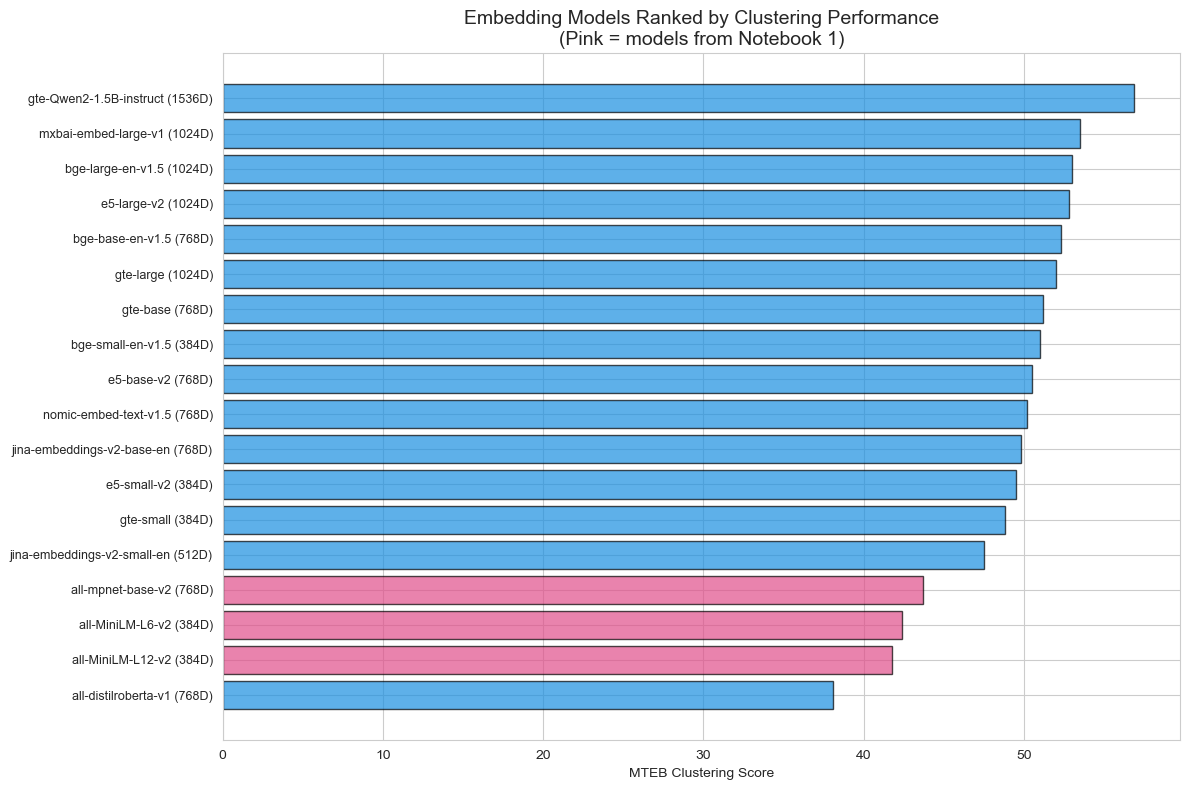

In [20]:
# Ranked by clustering score (most relevant for BERTopic)
ranked = mteb_df.sort_values('clustering', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e04e8a' if any(x in n for x in ['MiniLM', 'mpnet']) else '#1a8fe0' 
          for n in ranked['model_name']]

ax.barh(range(len(ranked)), ranked['clustering'], color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(ranked)))
ax.set_yticklabels([f"{row['model_name'][:30]} ({row['dimensions']}D)" 
                    for _, row in ranked.iterrows()], fontsize=9)
ax.set_xlabel('MTEB Clustering Score')
ax.set_title('Embedding Models Ranked by Clustering Performance\n(Pink = models from Notebook 1)', fontsize=14)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

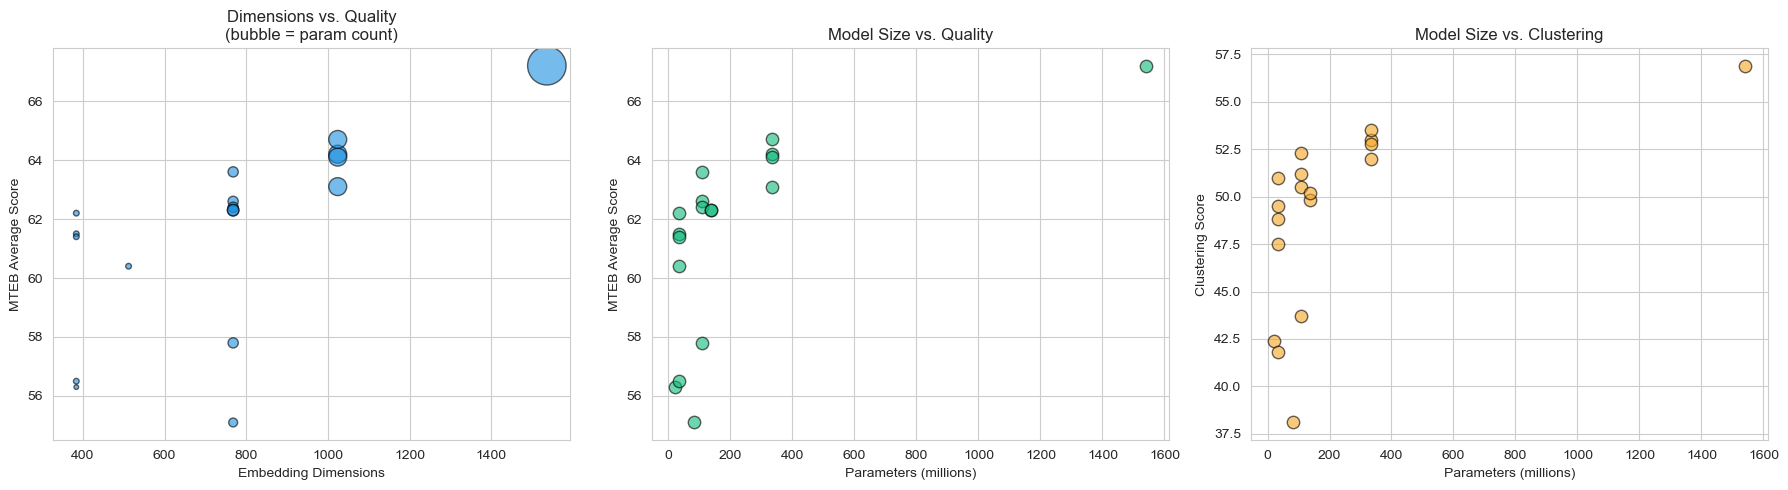

Bigger models score higher, but with diminishing returns.
The jump from 384→768 matters more than 768→1024.


In [21]:
# Dimensions vs. quality — does bigger always mean better?
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(mteb_df['dimensions'], mteb_df['mteb_avg'], 
                s=mteb_df['params_millions'] * 0.5, alpha=0.6, c='#1a8fe0', edgecolors='black')
axes[0].set_xlabel('Embedding Dimensions')
axes[0].set_ylabel('MTEB Average Score')
axes[0].set_title('Dimensions vs. Quality\n(bubble = param count)')

axes[1].scatter(mteb_df['params_millions'], mteb_df['mteb_avg'],
                s=80, alpha=0.6, c='#0eba7a', edgecolors='black')
axes[1].set_xlabel('Parameters (millions)')
axes[1].set_ylabel('MTEB Average Score')
axes[1].set_title('Model Size vs. Quality')

axes[2].scatter(mteb_df['params_millions'], mteb_df['clustering'],
                s=80, alpha=0.6, c='#f5a623', edgecolors='black')
axes[2].set_xlabel('Parameters (millions)')
axes[2].set_ylabel('Clustering Score')
axes[2].set_title('Model Size vs. Clustering')

plt.tight_layout()
plt.show()

print("Bigger models score higher, but with diminishing returns.")
print("The jump from 384→768 matters more than 768→1024.")

---
# Section 3: Connecting Ecosystem + Quality
---

Merge HuggingFace download data with MTEB quality scores.

In [22]:
# Merge
merged = pd.merge(mteb_df, hf_df[['model_id', 'downloads', 'likes']], on='model_id', how='left')
merged = merged.sort_values('clustering', ascending=False)

print("Combined: Quality + Popularity")
print("=" * 100)
display_cols = ['model_name', 'dimensions', 'params_millions', 'clustering', 'mteb_avg', 'downloads', 'likes']
display = merged[display_cols].copy()
display['downloads'] = display['downloads'].apply(lambda x: f"{x:,.0f}" if pd.notna(x) else 'N/A')
print(display.to_string(index=False))

Combined: Quality + Popularity
                 model_name  dimensions  params_millions  clustering  mteb_avg   downloads  likes
    gte-Qwen2-1.5B-instruct        1536             1540        56.9      67.2     394,241    229
       mxbai-embed-large-v1        1024              335        53.5      64.7   1,739,352    773
          bge-large-en-v1.5        1024              335        53.0      64.2   6,034,342    633
                e5-large-v2        1024              335        52.8      64.1   1,240,946    276
           bge-base-en-v1.5         768              109        52.3      63.6   5,046,233    405
                  gte-large        1024              335        52.0      63.1   1,433,430    299
                   gte-base         768              109        51.2      62.4     243,466    131
          bge-small-en-v1.5         384               33        51.0      62.2   7,742,207    421
                 e5-base-v2         768              109        50.5      62.6   1,407,

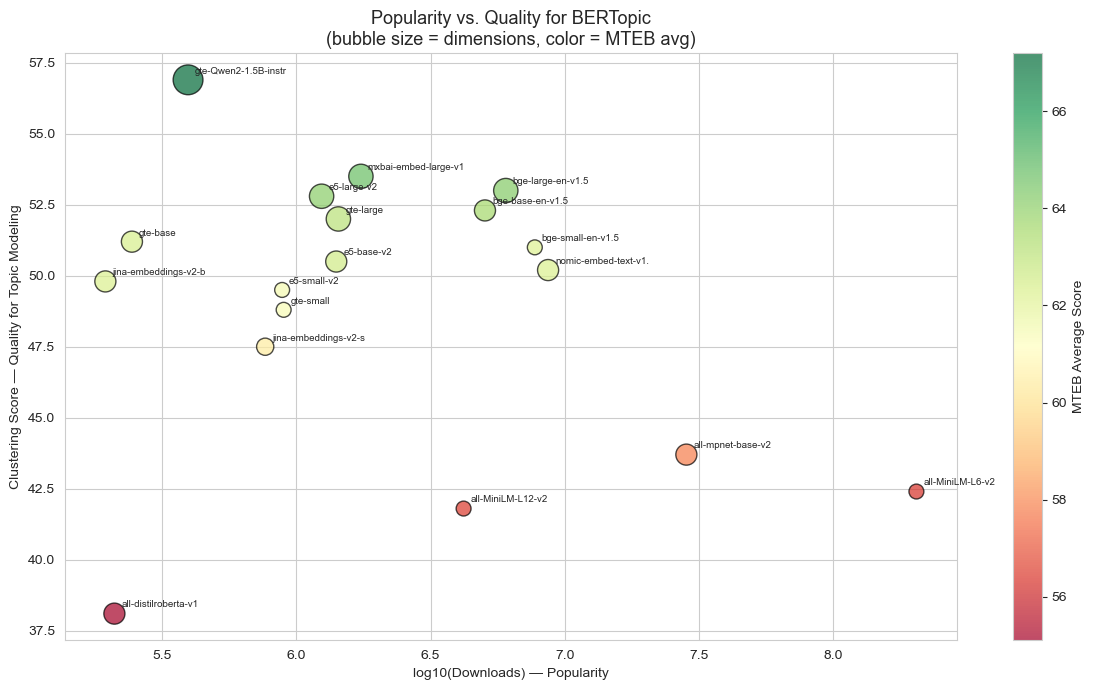

Top-right = popular AND high quality. Top-left = hidden gems.
Bottom-right = popular but not the best (legacy/convenience).


In [23]:
# Popularity vs. Quality scatter
plot_df = merged[merged['downloads'].notna() & (merged['downloads'] > 0)].copy()

if len(plot_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))
    scatter = ax.scatter(
        np.log10(plot_df['downloads']), plot_df['clustering'],
        s=plot_df['dimensions'] * 0.3, c=plot_df['mteb_avg'],
        cmap='RdYlGn', edgecolors='black', alpha=0.7)
    
    for _, row in plot_df.iterrows():
        ax.annotate(row['model_name'][:20], 
                    (np.log10(row['downloads']), row['clustering']),
                    fontsize=7, ha='left', va='bottom', xytext=(5, 3), textcoords='offset points')
    
    plt.colorbar(scatter, label='MTEB Average Score')
    ax.set_xlabel('log10(Downloads) — Popularity')
    ax.set_ylabel('Clustering Score — Quality for Topic Modeling')
    ax.set_title('Popularity vs. Quality for BERTopic\n(bubble size = dimensions, color = MTEB avg)', fontsize=13)
    plt.tight_layout()
    plt.show()
    
    print("Top-right = popular AND high quality. Top-left = hidden gems.")
    print("Bottom-right = popular but not the best (legacy/convenience).")

In [24]:
# Decision framework for BERTopic
print("=" * 80)
print("MODEL SELECTION FOR BERTOPIC")
print("=" * 80)

print("\n1. Speed-first (large corpus, prototyping):")
fast = mteb_df[mteb_df['dimensions'] <= 384].sort_values('clustering', ascending=False)
if len(fast) > 0:
    print(f"   → {fast.iloc[0]['model_name']} ({fast.iloc[0]['dimensions']}D, clustering={fast.iloc[0]['clustering']})")

print("\n2. Quality-first (final analysis):")
best = mteb_df.sort_values('clustering', ascending=False)
print(f"   → {best.iloc[0]['model_name']} ({best.iloc[0]['dimensions']}D, clustering={best.iloc[0]['clustering']})")

print("\n3. Balanced (recommended starting point):")
bal = mteb_df[(mteb_df['dimensions'] <= 768)].sort_values('clustering', ascending=False)
print(f"   → {bal.iloc[0]['model_name']} ({bal.iloc[0]['dimensions']}D, clustering={bal.iloc[0]['clustering']})")

print("\n4. Long document support (>512 tokens):")
long = mteb_df[mteb_df['max_tokens'] >= 2048].sort_values('clustering', ascending=False)
if len(long) > 0:
    print(f"   → {long.iloc[0]['model_name']} (max_tokens={long.iloc[0]['max_tokens']}, clustering={long.iloc[0]['clustering']})")

print("\n" + "=" * 80)
print("Start fast, upgrade if topics aren't good enough.")

MODEL SELECTION FOR BERTOPIC

1. Speed-first (large corpus, prototyping):
   → bge-small-en-v1.5 (384D, clustering=51.0)

2. Quality-first (final analysis):
   → gte-Qwen2-1.5B-instruct (1536D, clustering=56.9)

3. Balanced (recommended starting point):
   → bge-base-en-v1.5 (768D, clustering=52.3)

4. Long document support (>512 tokens):
   → gte-Qwen2-1.5B-instruct (max_tokens=32768, clustering=56.9)

Start fast, upgrade if topics aren't good enough.


---
## Summary

In this notebook you:

1. **Pulled metadata for every model on HuggingFace** — libraries, tasks, downloads, publishers, dates
2. **Explored the full ecosystem** — library and task distributions, publisher analysis, growth over time
3. **Identified model types** — distinguished official models from fine-tuned variants, student projects, and GGUF quantizations using heuristic signals
4. **Applied compound filters** the website can't do — combining recency, popularity, task, library, and model type
5. **Analyzed embedding quality via MTEB** — compared models on clustering and classification benchmarks
6. **Connected popularity with quality** — found that downloads don't always correlate with benchmark performance

**Key insight:** Model selection is the most impactful decision in BERTopic. This notebook gives you the tools to make that choice based on data, not guesswork.

**Next:** Use these insights to choose models for Notebook 1, where you'll generate actual document embeddings.